In [5]:
%matplotlib inline
import ipywidgets as widgets
import numpy as np
import matplotlib as mpl
from numpy import diag
from numpy import cos, sin
from scipy.sparse.linalg import eigsh
from scipy.sparse.linalg import eigs
from scipy import sparse
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science'])
plt.rcParams['text.usetex'] = True
# Re-assert figure size and DPI to prevent style overrides
plt.rcParams.update({'figure.figsize': (3.2, 2.4), 'figure.dpi': 300})

In [6]:
class KitaevChain:
    def __init__(self, n_sites):
        self.n_sites = n_sites
        self.shape = (n_sites, n_sites)
        self.hamiltonian = None
        self.k_range = None

    def compute_hamiltonian(self, t, mu, d, perturbation):
        diag = np.ones([self.n_sites])

        # 1. tight-binding terms
        # 1.1. chemical potential
        # support scalar mu or site-dependent mu array
        mu_arr = mu * np.ones(self.n_sites) if np.isscalar(mu) else np.array(mu)
        mu_term = sparse.diags(-mu_arr)
        if perturbation:
            mu_term += self.sample_perturbation(perturbation)
        
        # 1.2. hopping terms
        t_term = t * sparse.diags([diag[:-1], diag[1:]], offsets=[-1, 1], shape=self.shape)

        # 2. pairing terms
        d_term = d * sparse.diags([-diag[:-1], diag[1:]], offsets=[-1, 1], shape=self.shape)

        # compile the BdG Hamiltonian
        top_left = mu_term + t_term # tight-binding terms
        top_right = d_term # pairing term
        bottom_left = top_right.T
        bottom_right = -top_left.T

        top_row = sparse.hstack((top_left, top_right))
        bottom_row = sparse.hstack((bottom_left, bottom_right))
        h = sparse.vstack((top_row, bottom_row))
        
        # # chemical potential bias term
        # b_mu_term = -1/2*mu_term
        # print(b_mu_term.shape, np.zeros(b_mu_term.shape).shape, b_mu_term.shape)
        # b_top_row = sparse.hstack((b_mu_term, np.zeros(b_mu_term.shape)))
        # b_bottom_row = sparse.hstack((np.zeros(b_mu_term.shape), -b_mu_term)) 
        # b = sparse.vstack((b_top_row, b_bottom_row))
        # return h + b
        return h

    def sample_perturbation(self, dmu):
        perturb_diag = np.random.uniform(-dmu, dmu, size=self.n_sites)
        return sparse.diags(perturb_diag)
    
    def build_hamiltonian(self, t, mu, d, perturbation=0):
        self.hamiltonian = self.compute_hamiltonian(t, mu, d, perturbation)

    def compute_eigensystem(self):
        if self.hamiltonian is None:
            raise ValueError("Build the Hamiltonian first using KitaevChain.build_hamiltonian().")
        return np.linalg.eigh(self.hamiltonian.toarray())
    
    def compute_hamiltonian_k(self, t, mu, d):
        h_k = (lambda k: 
               np.array([[2*t*cos(k)-mu, -2j*d*sin(k)],
                         [2j*d*sin(k), -2*t*cos(k)+mu]]))
        return h_k
    
    def build_hamiltonian_k(self, t, mu, d):
        self.hamiltonian_k = self.compute_hamiltonian_k(t, mu, d)
    
    def compute_energy_band(self):
        step = 2*np.pi/self.n_sites
        self.k_range = np.arange(-np.pi, np.pi + step/2, step)
        h_k_computed = np.array(list(map(self.hamiltonian_k, self.k_range)))
        return np.array(list(map(np.linalg.eigvals, h_k_computed)))

In [7]:
class BdGEigensystem:
    def __init__(self, eigval, eigfunc, mzm_threshold=1e-5):
        self.n_sites = len(eigfunc[0]) // 2
        self.eigval = eigval
        self.eigfunc = eigfunc
        self.mzm_threshold = mzm_threshold
        self.mzm_idx = np.where(np.abs(eigval) < mzm_threshold)[0]

    def get_mzm_eigenvals(self):
        return self.eigval[self.mzm_idx]

    def get_mzm_eigfuncs(self):
        # numpy.linalg.eigh/eigsh store eigenvectors in columns
        return self.eigfunc[:, self.mzm_idx]
    
    def plot_eigenval_spectrum(self, density=False, return_fig=False):
        fig = plt.hist(self.eigval, bins=51, density=density)
        plt.xlabel('Energy (E)')
        plt.ylabel('Density of States' if density else 'Count')
        plt.title('BdG Eigenvalue Spectrum')
        return fig if return_fig else None

    def compute_spatial_distribution(self, eigfunc=False):
        u_v = self.split_eigensystem(eigfunc)
        return np.sum(np.abs(u_v)**2, axis=0)
    
    def plot_spatial_distribution(self, eigfunc, return_fig=False):
        fig = plt.plot(self.compute_spatial_distribution(eigfunc))
        plt.xlabel('Site Index')
        plt.ylabel(r'$|u_i|^2 + |v_i|^2$')
        plt.title('Spatial Distribution of Eigenmode')
        return fig if return_fig else None
    
    def plot_spatial_distribution_cdf(self, eigfunc, return_fig=False):
        spatial_dist = self.compute_spatial_distribution(eigfunc)
        cdf = np.array(spatial_dist)
        moving_sum = 0
        for i in range(self.n_sites):
            cdf[i] = spatial_dist[i] + moving_sum
            moving_sum += spatial_dist[i]
        fig = plt.plot(cdf)
        plt.xlabel('Site Index')
        plt.ylabel('Cumulative Probability')
        plt.title('CDF of Spatial Distribution')
        return fig if return_fig else None
        
    def compute_u_v_amp_diff(self, eigfunc_list):
        # eigfunc_list follows eigsh/eigh convention: shape (2N, M), columns are eigenmodes.
        diffs = []
        for i in range(eigfunc_list.shape[1]):
            u, v = self.split_eigensystem(eigfunc_list[:, i])
            diffs.append(np.sum(np.abs(u)**2) - np.sum(np.abs(v)**2))
        return np.array(diffs)

    def split_eigensystem(self, eigfunc_or_val):
        return np.array((eigfunc_or_val[:self.n_sites], eigfunc_or_val[self.n_sites:]))

In [8]:
def plot_energy_band(chain, t, mu, d):
    chain.build_hamiltonian_k(t=t, mu=mu, d=d)
    e_bands = chain.compute_energy_band().T
    plt.scatter(chain.k_range, e_bands[0], s=1, color='blue', label='Conduction Band')
    plt.scatter(chain.k_range, e_bands[1], s=1, color='blue', label='Valence Band')
    plt.xlabel(r'$k$')
    plt.ylabel('Energy (E)')
    plt.title('Kitaev Chain Energy Band')

In [9]:
plt.close()
N = 500
t=1.0
mu=1.0
d=2.0

chain = KitaevChain(n_sites=N)
chain.build_hamiltonian(t=t, mu=mu, d=d)
print(chain.hamiltonian.shape)

eig_sys = BdGEigensystem(*chain.compute_eigensystem())

(1000, 1000)


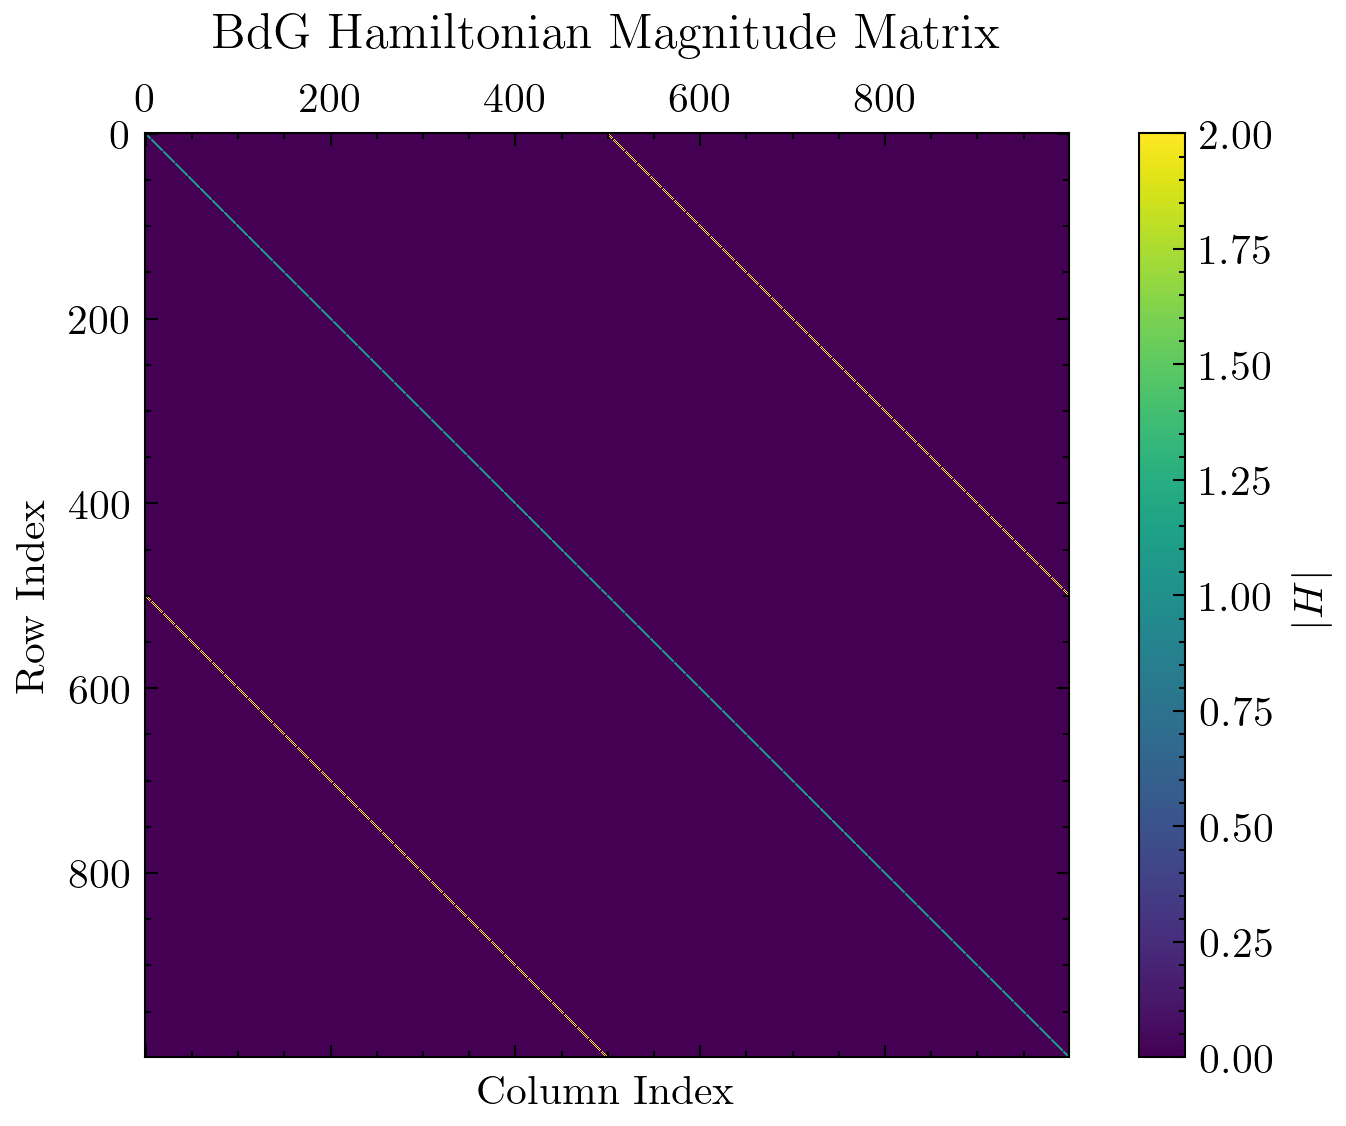

In [10]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.matshow(np.abs(chain.hamiltonian.toarray()), cmap='viridis')
ax.set_title('BdG Hamiltonian Magnitude Matrix', pad=8)
ax.set_xlabel('Column Index')
ax.set_ylabel('Row Index')
fig.colorbar(im, ax=ax, label=r'$|H|$')
plt.show()

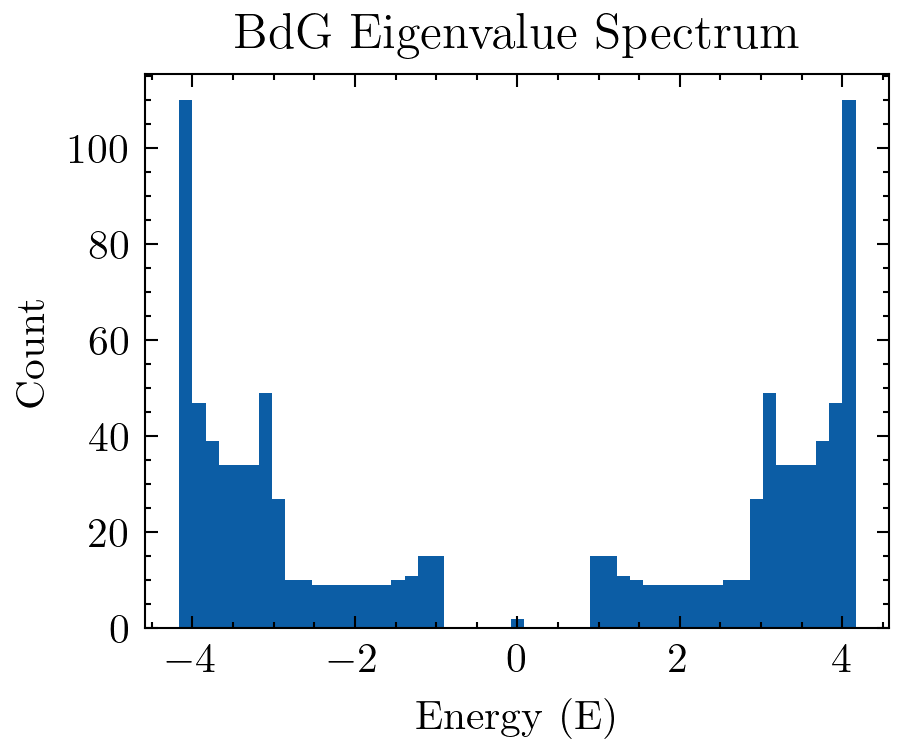

In [11]:
%matplotlib inline

eig_sys.plot_eigenval_spectrum()

MZM eigenvalue(s): [-7.00498449e-16 -4.39234517e-16]


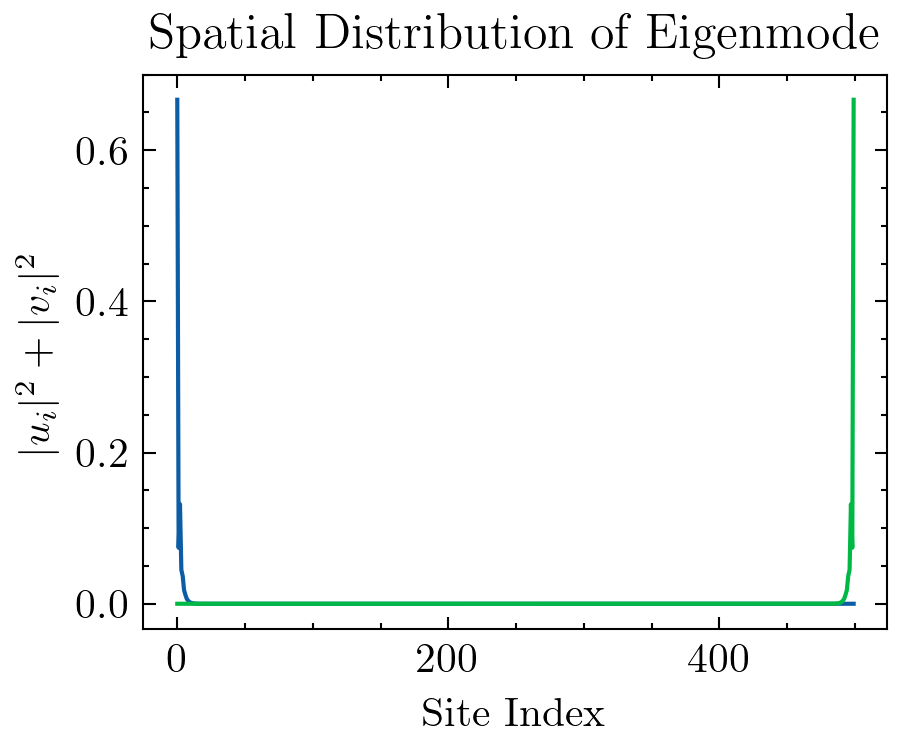

In [13]:
%matplotlib inline
mzm_idx = eig_sys.mzm_idx
print("MZM eigenvalue(s):", eig_sys.get_mzm_eigenvals())
eig_sys.plot_spatial_distribution(eig_sys.eigfunc[:, mzm_idx[0]])
eig_sys.plot_spatial_distribution(eig_sys.eigfunc[:, mzm_idx[1]])

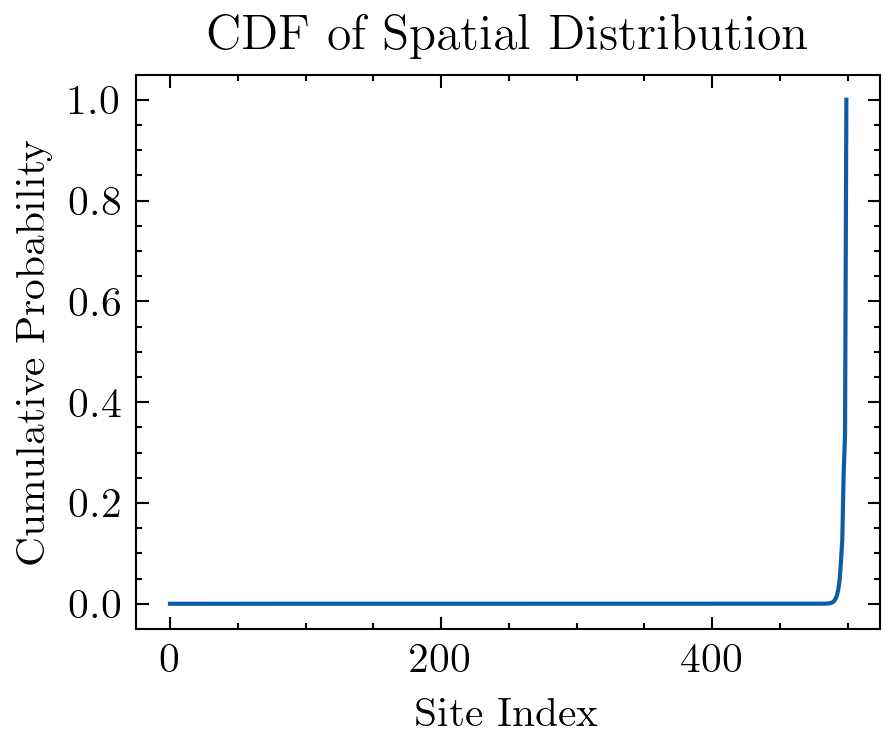

In [14]:
# eig_sys.plot_spatial_distribution_cdf(eig_sys.eigfunc[:, mzm_idx[0]])
eig_sys.plot_spatial_distribution_cdf(eig_sys.eigfunc[:, mzm_idx[1]])

Text(0.5, 1.0, 'Electron-Hole Imbalance vs Energy')

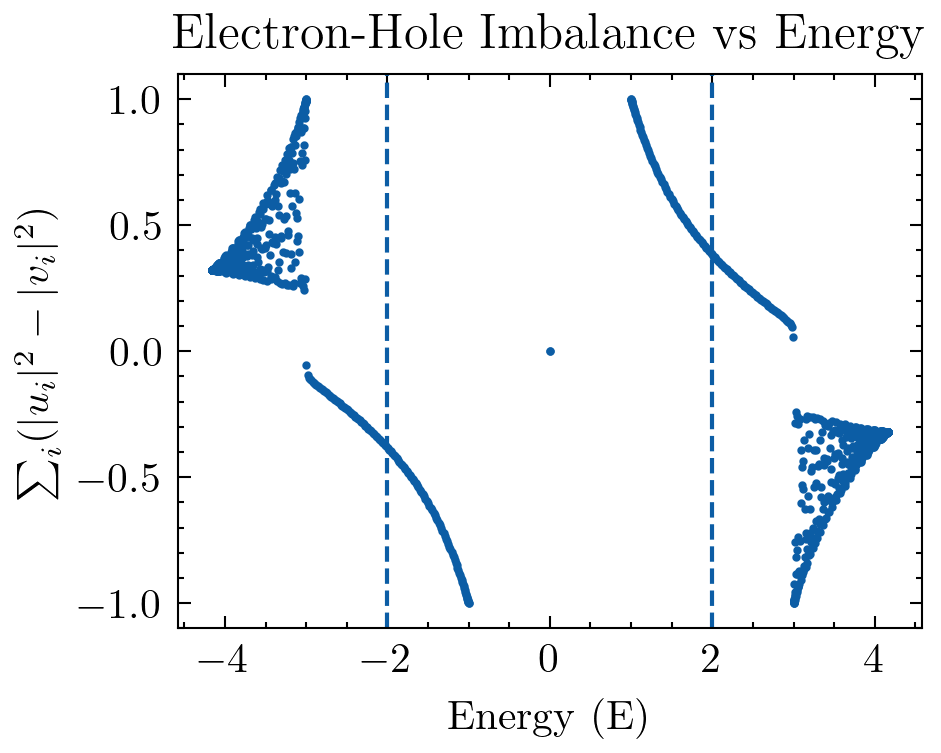

In [15]:
%matplotlib inline

# $|u|^2$ - $|v|^2$
u_v_amp_diff = eig_sys.compute_u_v_amp_diff(eig_sys.eigfunc)
u_v_amp_diff_mzm = eig_sys.compute_u_v_amp_diff(eig_sys.eigfunc[:, mzm_idx])

plt.ylim([-1.1, 1.1])
plt.axvline(d, linestyle='--', label=f'E={d}')
plt.axvline(-d, linestyle='--', label=f'E={-d}')
plt.scatter(eig_sys.eigval, u_v_amp_diff, s=1)
plt.xlabel('Energy (E)')
plt.ylabel(r'$\sum_i (|u_i|^2 - |v_i|^2)$')
plt.title('Electron-Hole Imbalance vs Energy')
# plt.scatter(eig_sys.eigval[mzm_idx], u_v_amp_diff_mzm, s=10, color='red')

/mnt/d/data/YSH/data/2026 Senior Spring/00 PHYS495 Condensed Matter Physics/final project/MZM_simulation/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/d/data/YSH/data/2026 Senior Spring/00 PHYS495 Condensed Matter Physics/final project/MZM_simulation/.venv/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


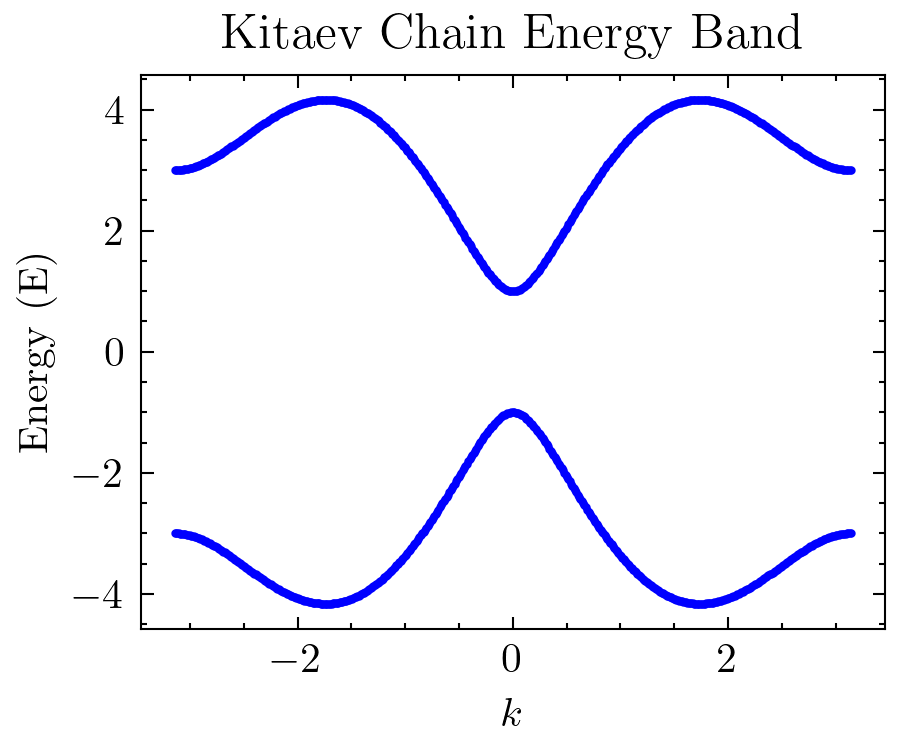

In [51]:
%matplotlib inline

plot_energy_band(chain, t, mu, d)

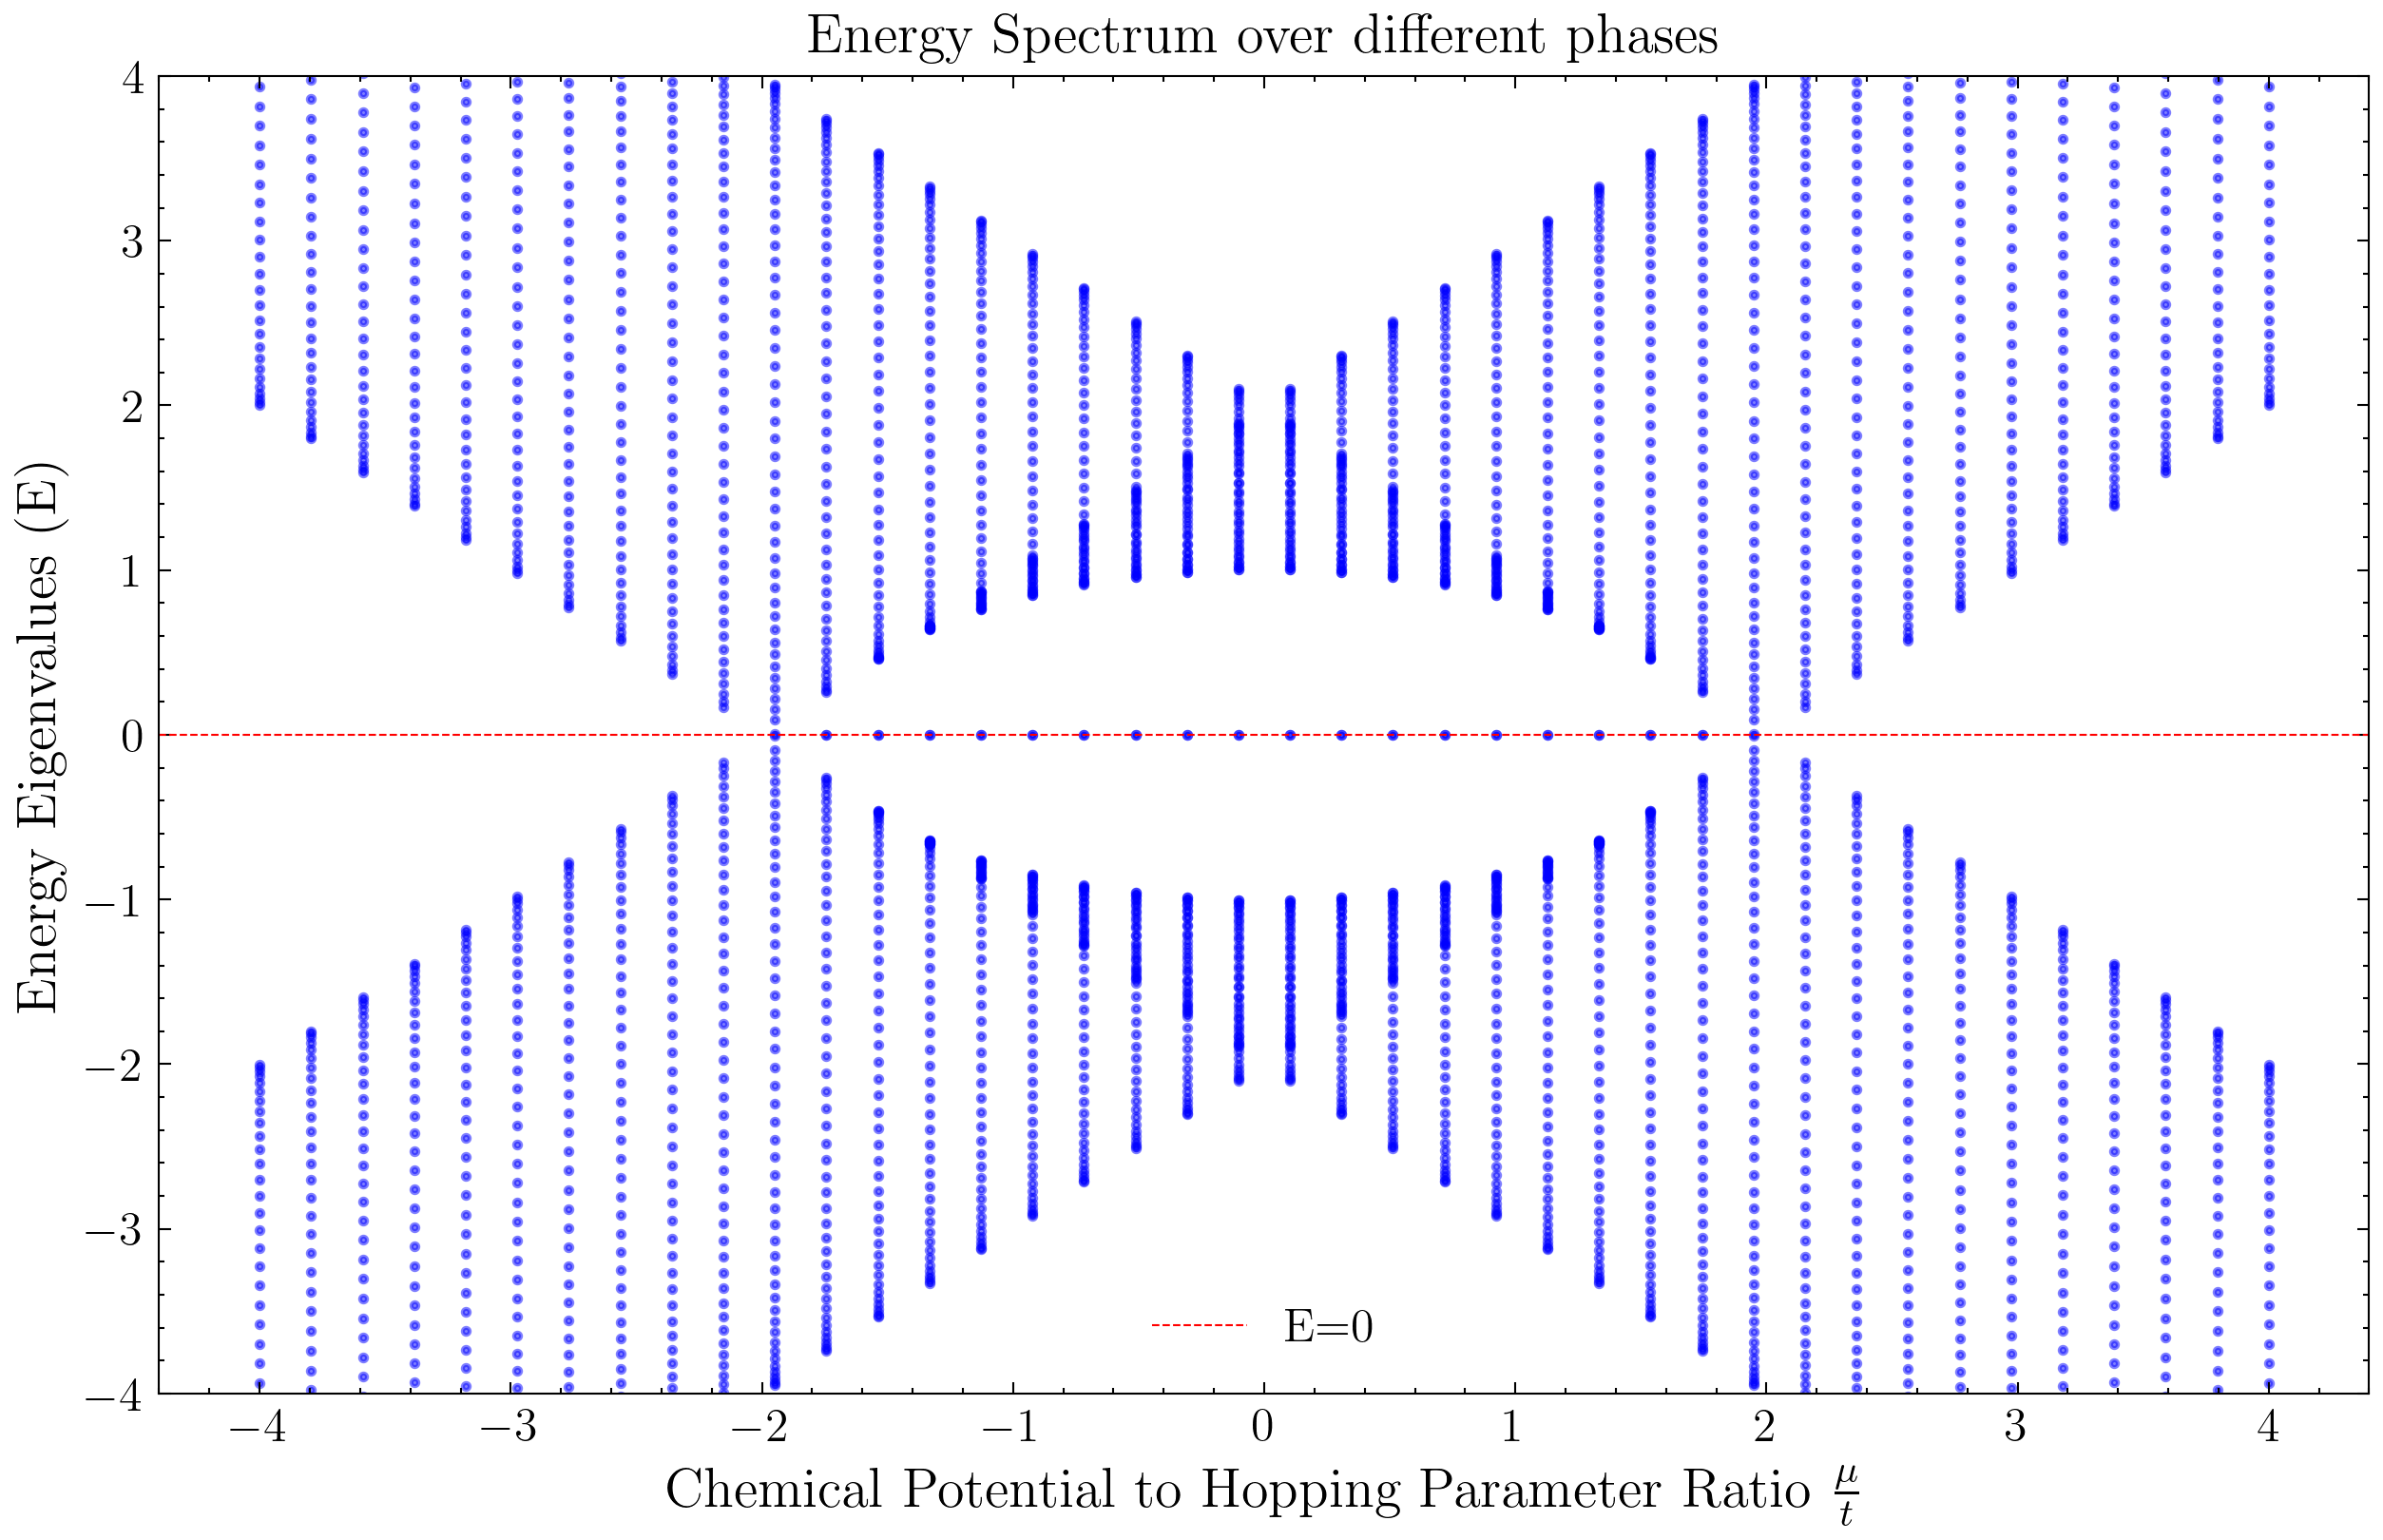

In [52]:
%matplotlib inline

N = 50
chain = KitaevChain(n_sites=N)
t = 1.0
delta = 0.5
delta = 0.5
mu_range = np.linspace(-4.0, 4.0, 40)

all_energies = []
for mu_i in mu_range:
    h = chain.compute_hamiltonian(t, mu_i, delta, perturbation=0)
    eigvals, _ = np.linalg.eigh(h.toarray())
    all_energies.extend(eigvals)

plt.figure(figsize=(10, 6))
font_size = 14
plt.scatter(np.array([mu_range]*N*2).T.reshape(-1) / t, all_energies, s=3, color='blue', alpha=0.5)

plt.axhline(0, color='red', linestyle='--', linewidth=0.5, label='E=0')
plt.title('Energy Spectrum over different phases', fontsize=font_size)
plt.xlabel(r'$\text{Chemical Potential to Hopping Parameter Ratio }\frac{\mu}{t}$', fontsize=font_size)
plt.ylabel('Energy Eigenvalues (E)', fontsize=font_size)
plt.ylim(-4, 4)
leg = plt.legend(fontsize=font_size-2)
plt.xticks(fontsize=font_size-2)
plt.yticks(fontsize=font_size-2)
plt.show()

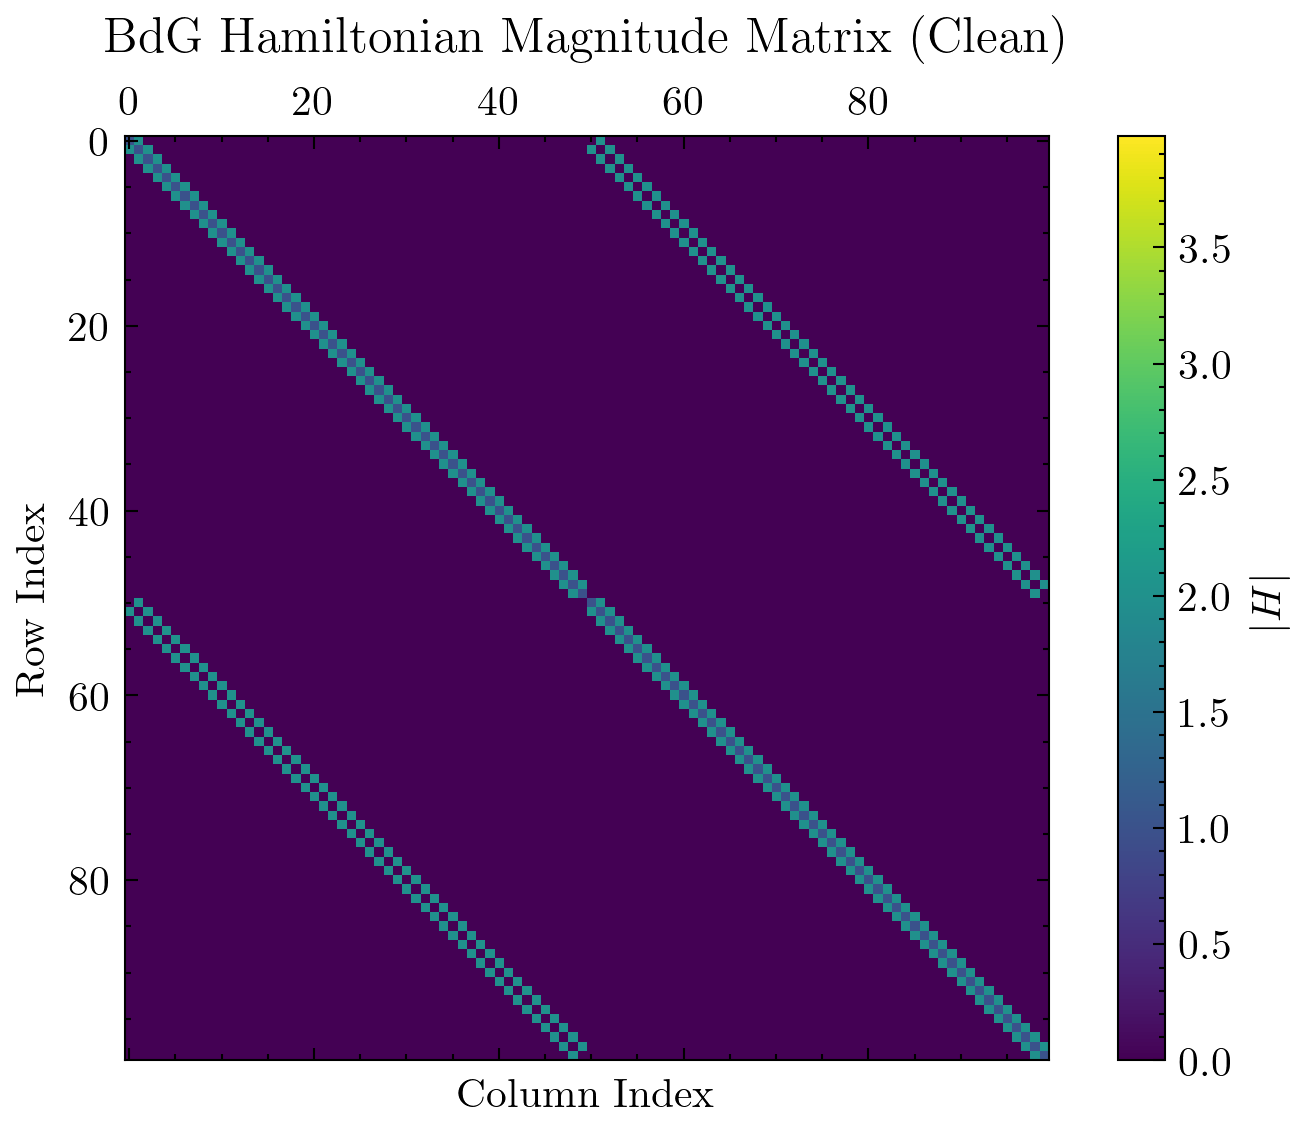

In [53]:
%matplotlib inline

t = 2.0
mu = 1
delta = 0.5

N = 50

chain1 = KitaevChain(N)
chain1.build_hamiltonian(t=t, mu=mu, d=d)

chain2 = KitaevChain(N)
chain2.build_hamiltonian(t=t, mu=mu, d=d, perturbation=3*mu)

# Compute absolute Hamiltonian matrices and a shared color scale
H1 = np.abs(chain1.hamiltonian.toarray())
H2 = np.abs(chain2.hamiltonian.toarray())
vmin = min(H1.min(), H2.min())
vmax = max(H1.max(), H2.max())

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.matshow(H1, cmap='viridis', vmin=vmin, vmax=vmax)
ax.set_title('BdG Hamiltonian Magnitude Matrix (Clean)', pad=8)
ax.set_xlabel('Column Index')
ax.set_ylabel('Row Index')
fig.colorbar(im, ax=ax, label=r'$|H|$')
plt.show()

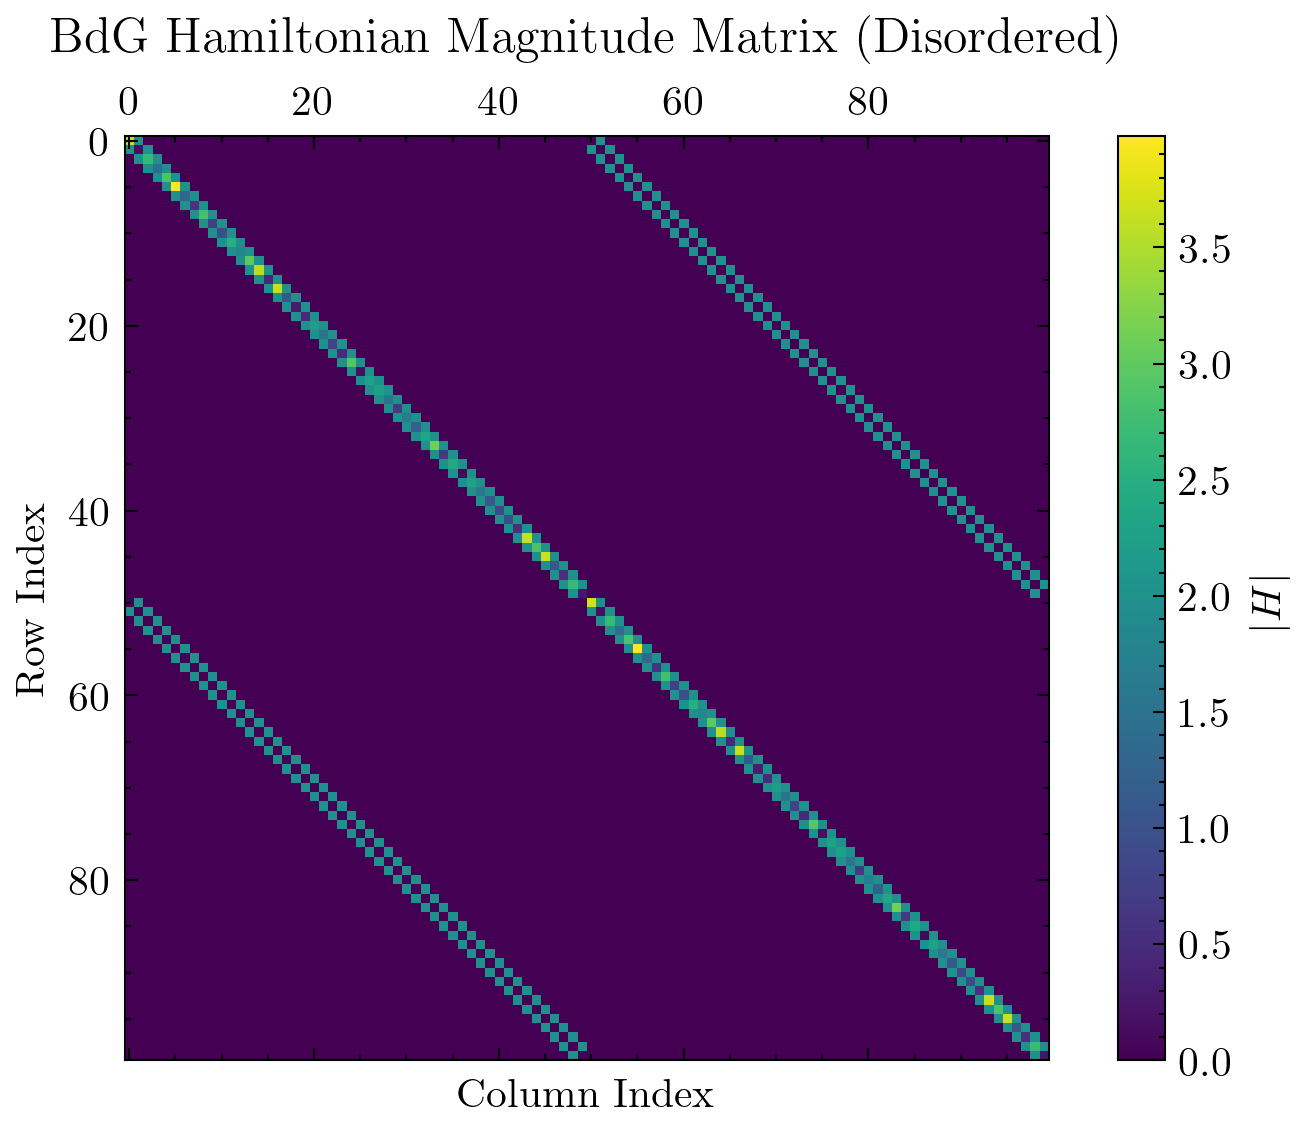

In [54]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.matshow(np.abs(chain2.hamiltonian.toarray()), cmap='viridis', vmin=vmin, vmax=vmax)
ax.set_title('BdG Hamiltonian Magnitude Matrix (Disordered)', pad=8)
ax.set_xlabel('Column Index')
ax.set_ylabel('Row Index')
fig.colorbar(im, ax=ax, label=r'$|H|$')
plt.show()

In [55]:
%matplotlib inline
eig_sys1 = BdGEigensystem(*chain1.compute_eigensystem())
eig_sys2 = BdGEigensystem(*chain2.compute_eigensystem())

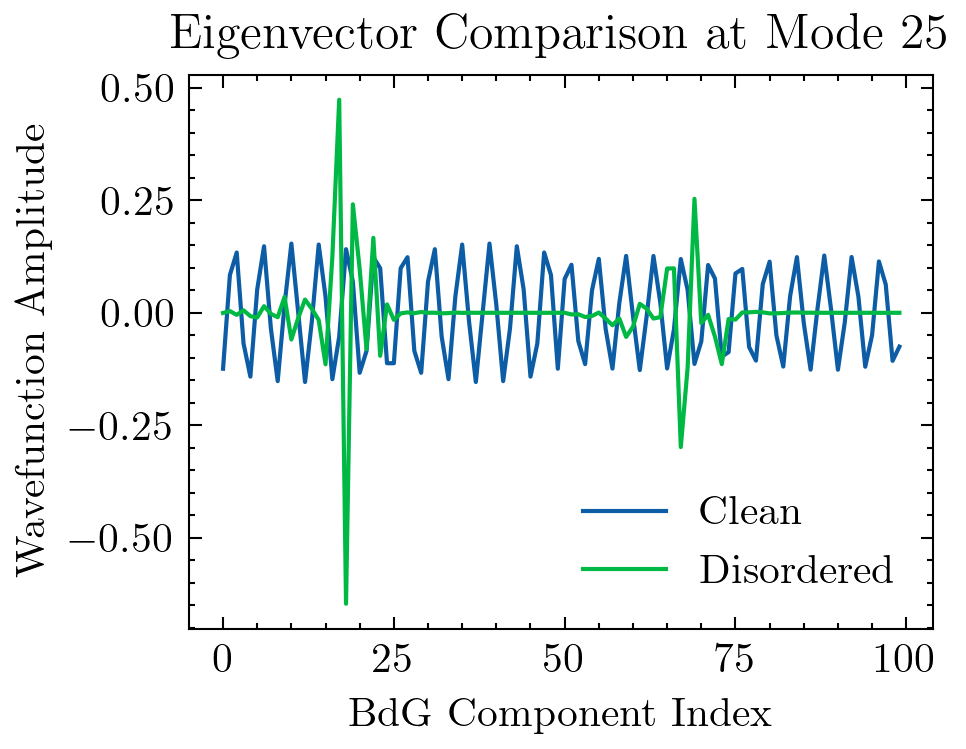

In [56]:
%matplotlib inline
i = 25
plt.plot(eig_sys1.eigfunc[:, i], label='Clean')
plt.plot(eig_sys2.eigfunc[:, i], label='Disordered')
plt.xlabel('BdG Component Index')
plt.ylabel('Wavefunction Amplitude')
plt.title(f'Eigenvector Comparison at Mode {i}')
plt.legend()

In [57]:
# %matplotlib inline
# assert (eig_sys1.mzm_idx.size != 0) and (eig_sys1.mzm_idx.size != 0) and (np.all(eig_sys1.mzm_idx == eig_sys2.mzm_idx))
# i = eig_sys1.mzm_idx[1]
# plt.plot(eig_sys1.eigfunc[:, i], label='Clean')
# plt.plot(eig_sys2.eigfunc[:, i], label='Disordered')
# plt.xlabel('BdG Component Index')
# plt.ylabel('Wavefunction Amplitude')
# plt.title(f'MZM Eigenvector Comparison at Mode {i}')
# plt.legend()

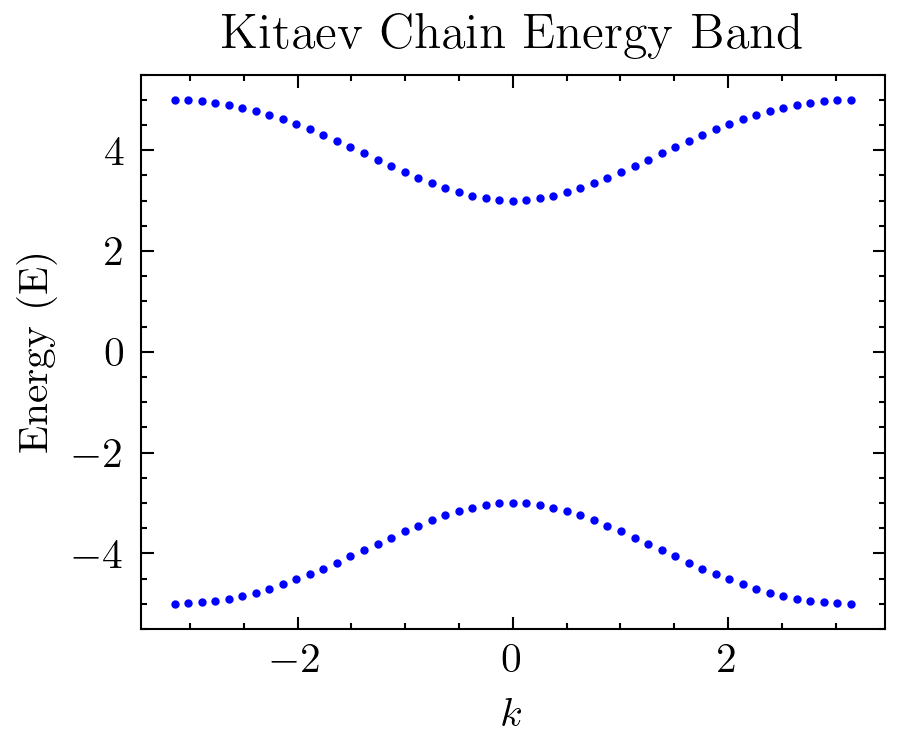

In [58]:
%matplotlib inline
plot_energy_band(chain1, t, mu, d)

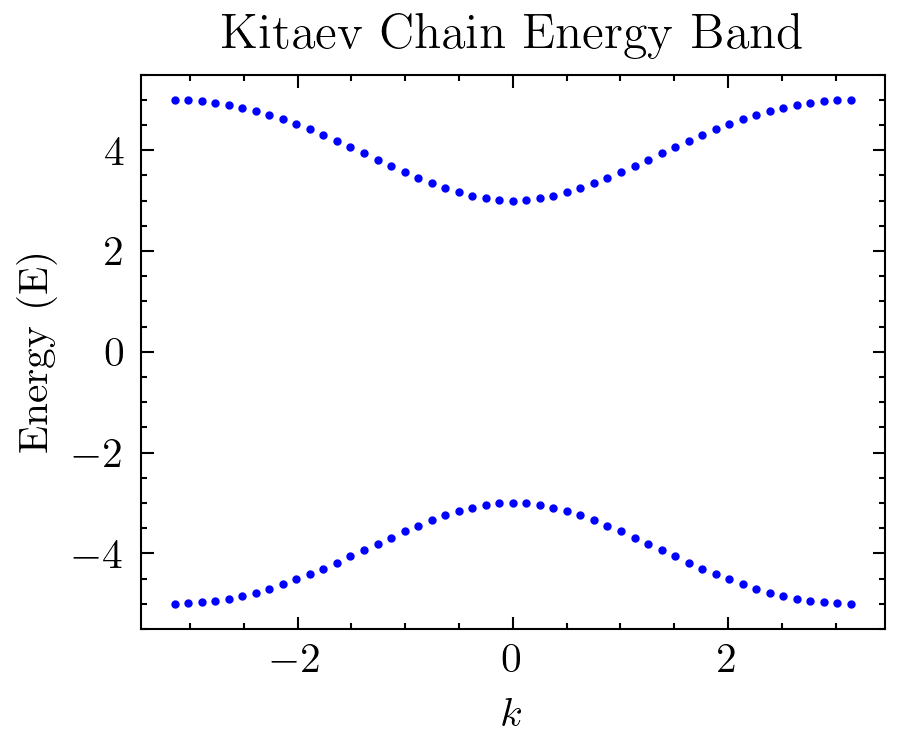

In [59]:
%matplotlib inline
plot_energy_band(chain2, t, mu, d)

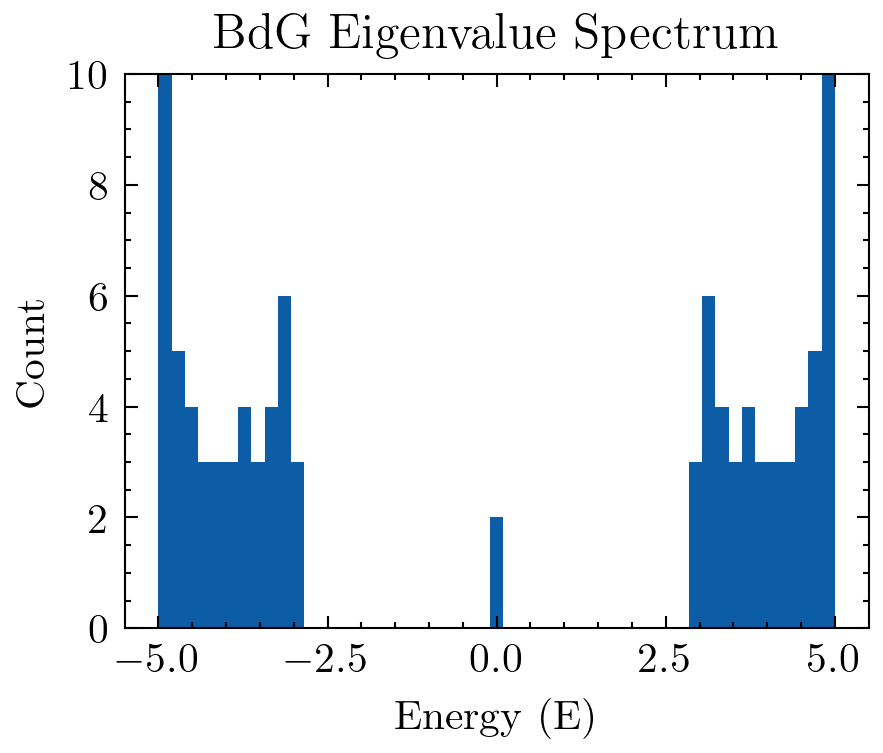

In [60]:
%matplotlib inline
plt.ylim([0, 10])
eig_sys1.plot_eigenval_spectrum()

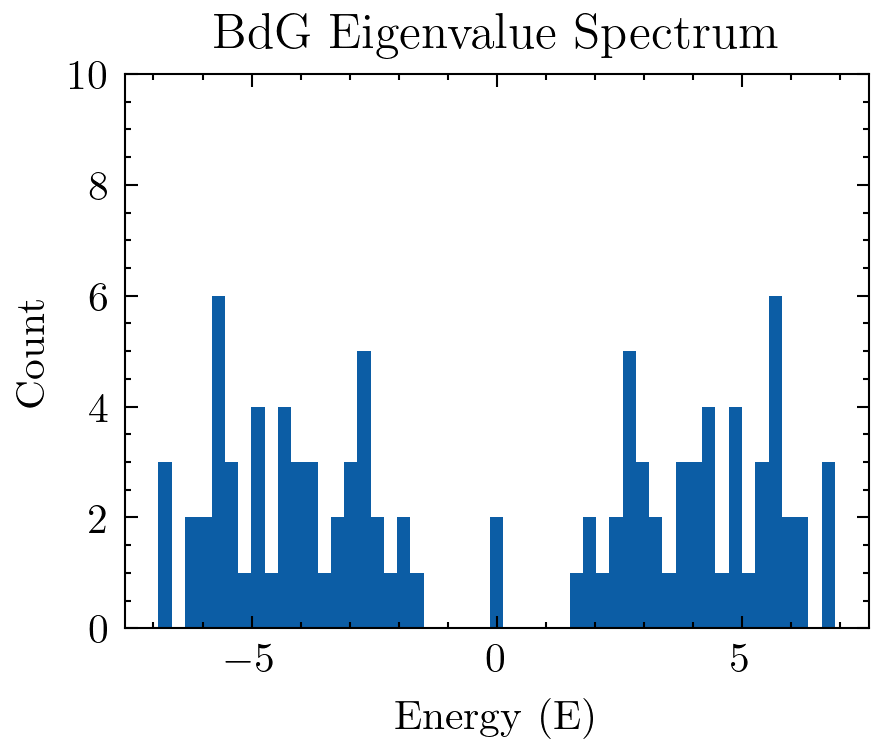

In [61]:
%matplotlib inline
plt.ylim([0, 10])
eig_sys2.plot_eigenval_spectrum()

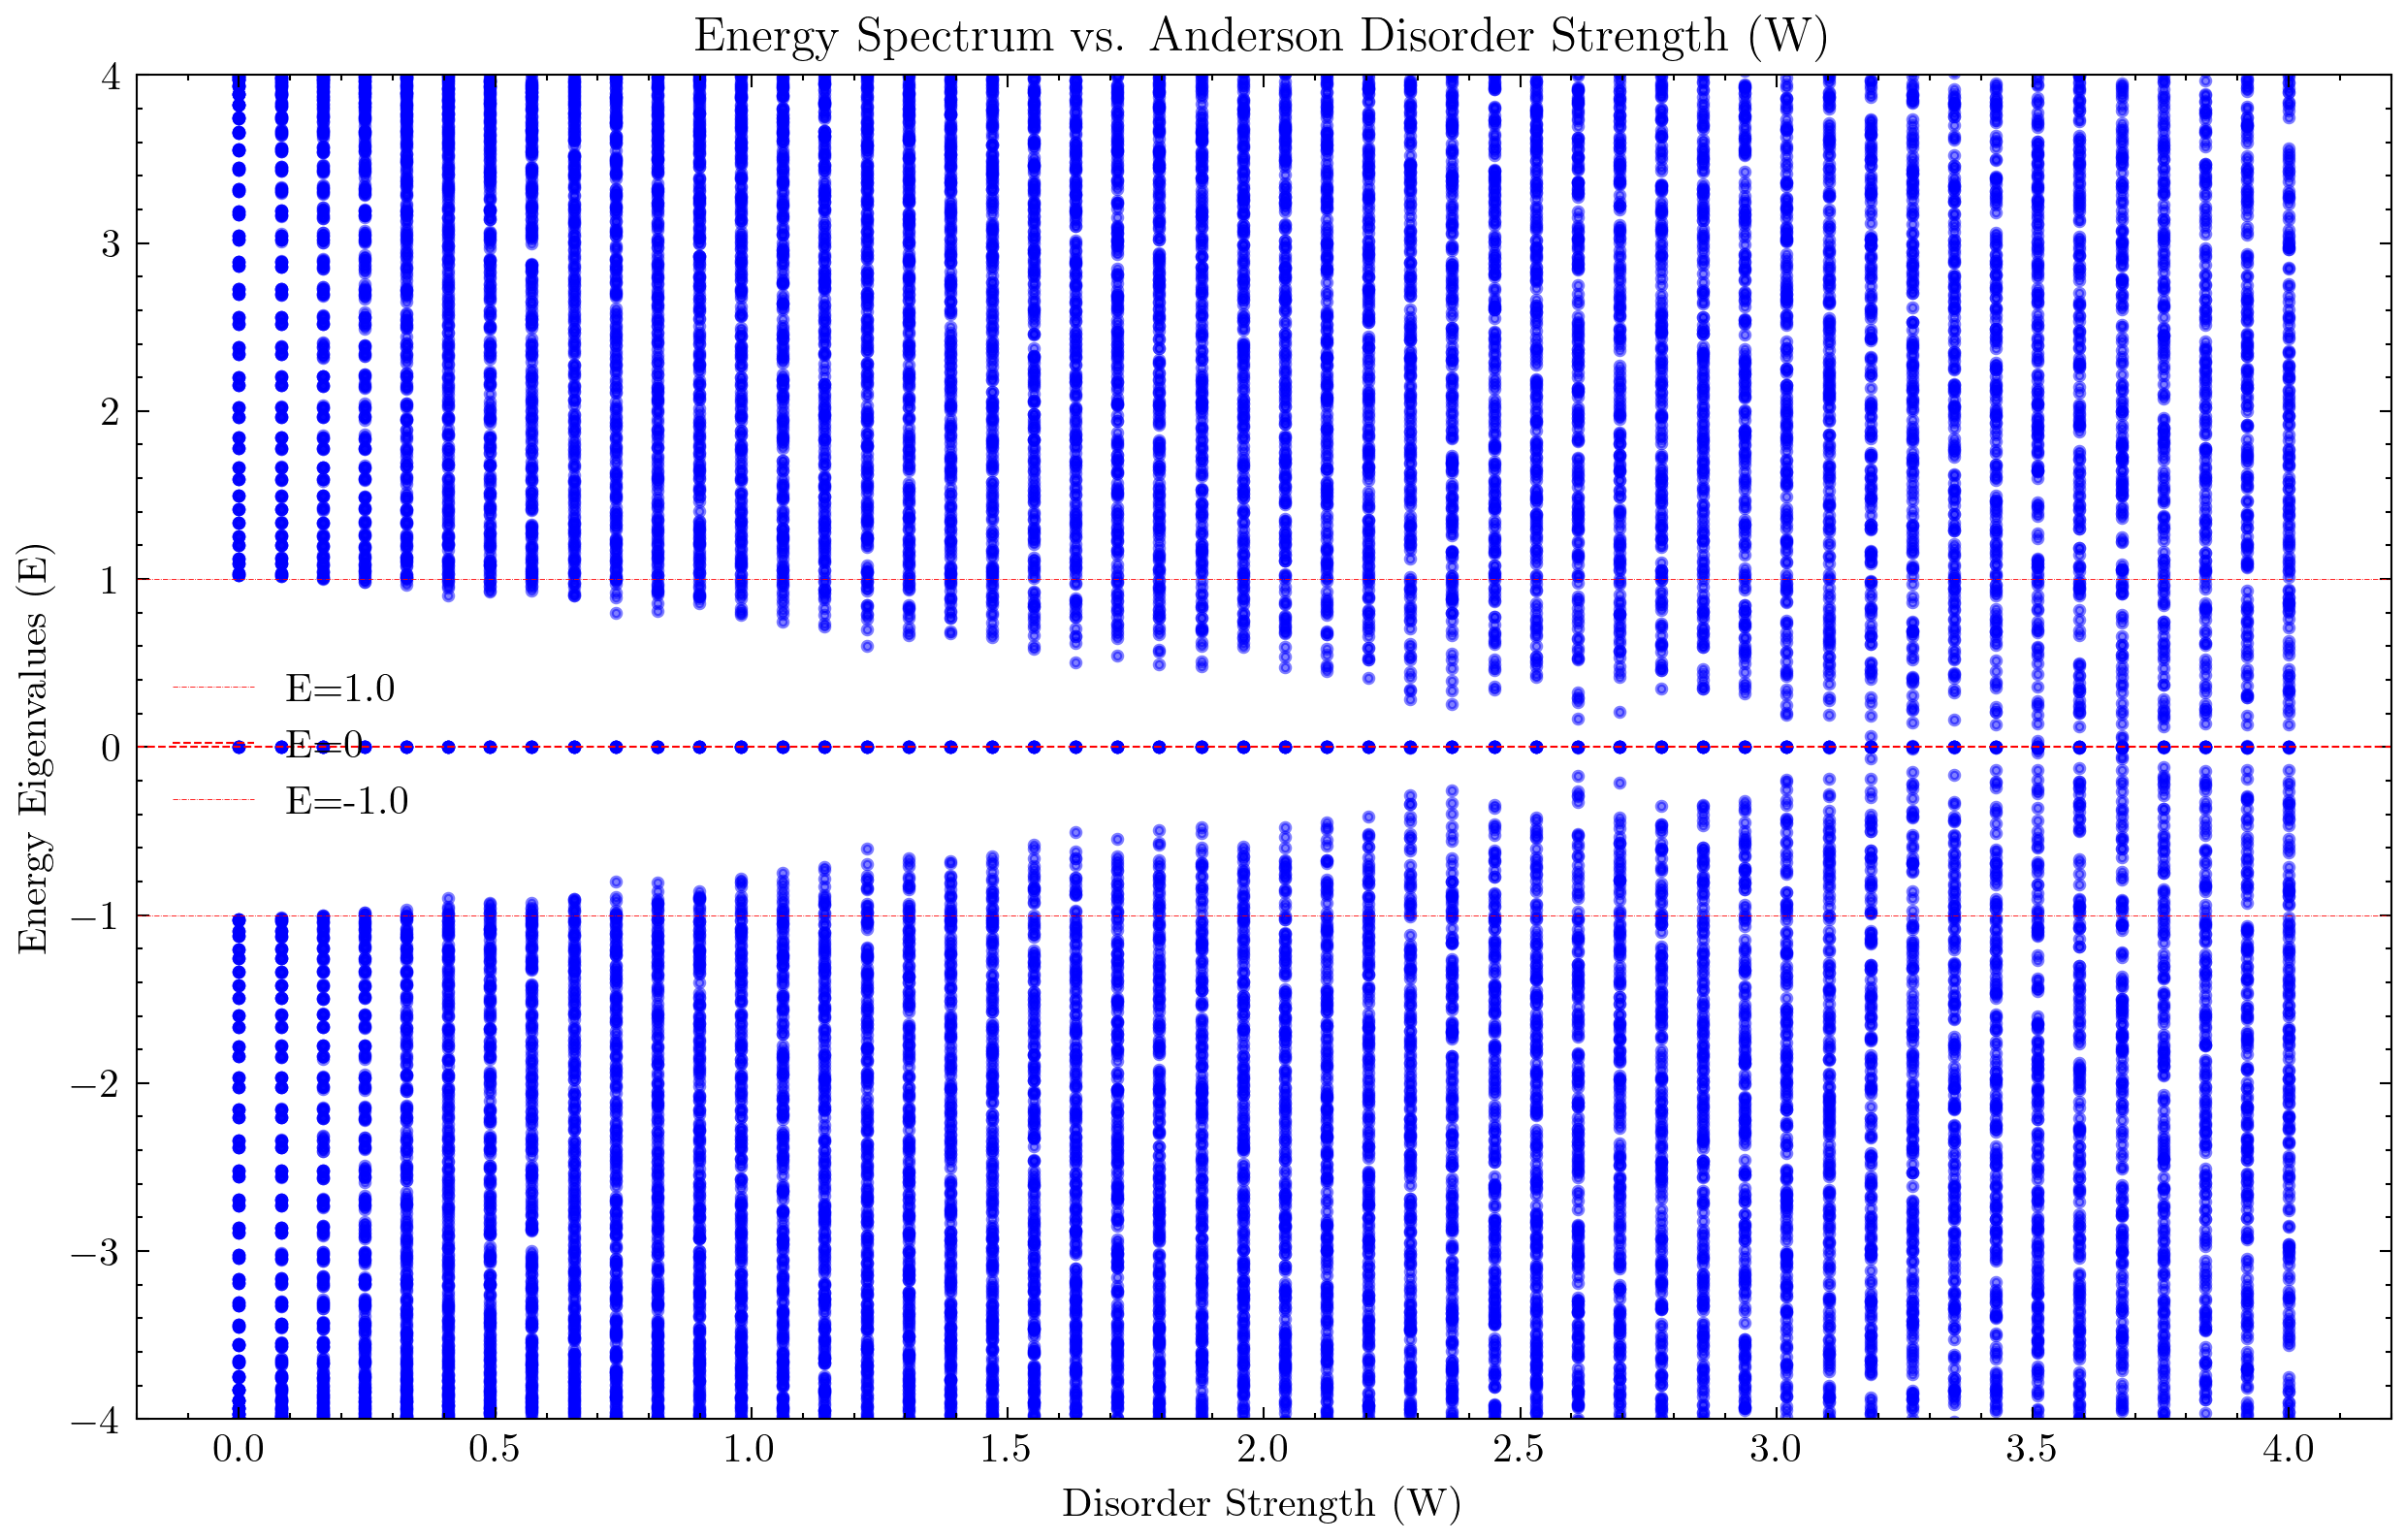

In [62]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# 1. Set up the baseline parameters
N = 50
t = 2.0
mu_clean = 0.0  # Deep in the topological phase
delta = 0.5
chain = KitaevChain(n_sites=N)

# 2. Define the range of disorder strengths (W)
W_values = np.linspace(0.0, 4.0, 50)
all_energies = []
all_W = []

# 3. Sweep through the disorder strengths
for W in W_values:
    # We do 5 random configurations per W to get a good average (disorder realization)
    for realization in range(5):
        # Generate the Anderson disorder: uniform noise between [-W, W]
        disorder = np.random.uniform(-W, W, N)
        
        # The total chemical potential is the clean baseline + the dirt
        mu_array = mu_clean * np.ones(N) + disorder
        
        # Build and solve
        h = chain.compute_hamiltonian(t, mu_array, delta, perturbation=0)
        eigvals, _ = np.linalg.eigh(h.toarray())
        
        # Save the data for plotting
        all_energies.extend(eigvals)
        all_W.extend([W] * len(eigvals)) # Keep track of which W these belong to

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(all_W, all_energies, s=5, color='blue', alpha=0.5)

plt.axhline(2*delta, color='red', linestyle='-.', linewidth=0.2, label=f'E={2*delta}')
plt.axhline(0, color='red', linestyle='--', linewidth=0.5, label='E=0')
plt.axhline(-2*delta, color='red', linestyle='-.', linewidth=0.2, label=f'E={-2*delta}')
plt.title('Energy Spectrum vs. Anderson Disorder Strength (W)')
plt.xlabel('Disorder Strength (W)')
plt.ylabel('Energy Eigenvalues (E)')
plt.ylim(-4, 4)
plt.legend()
plt.show()

interactive(children=(FloatSlider(value=1.0, description='t', max=5.0), FloatSlider(value=0.0, description='mu…

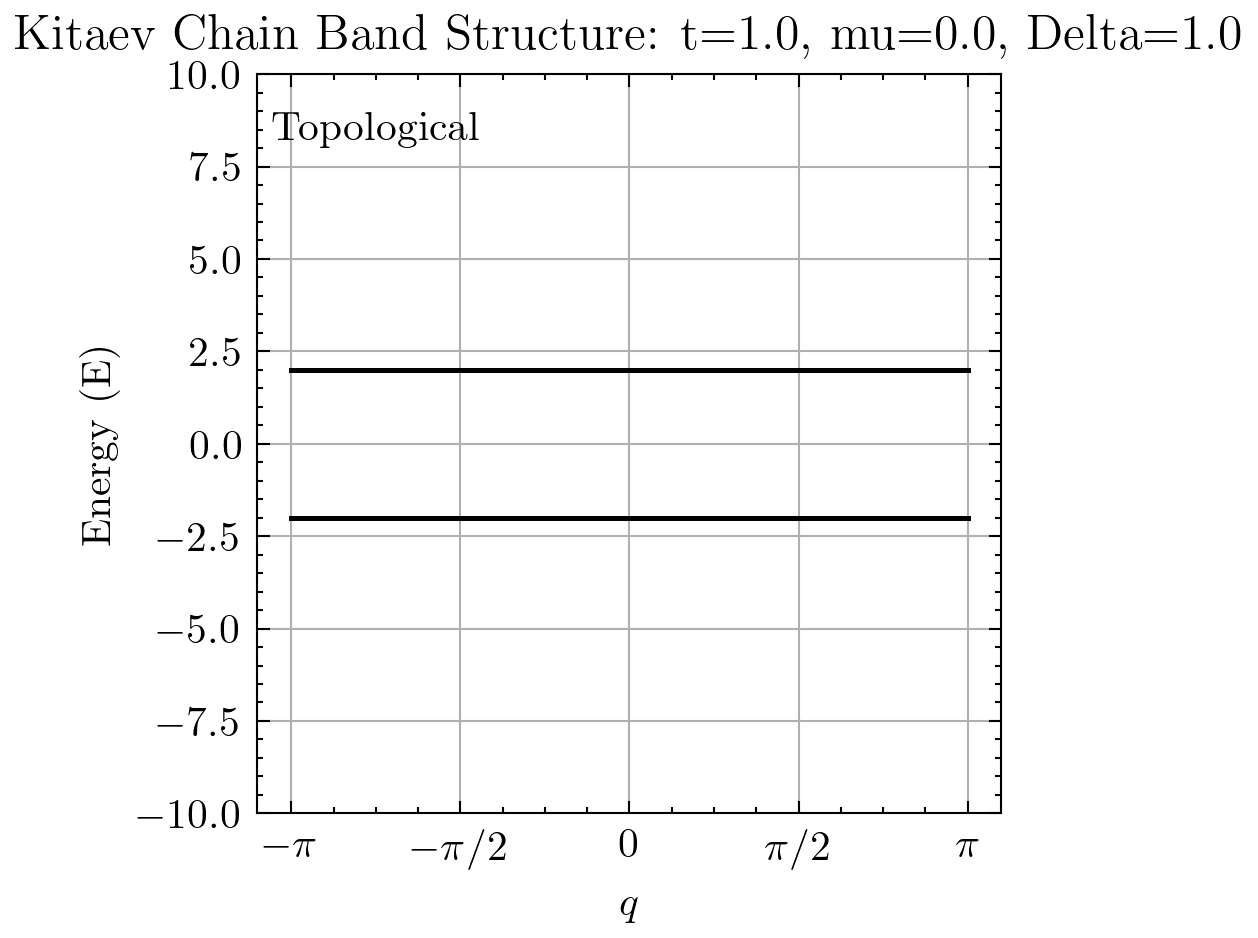

In [16]:
%matplotlib widget

# Use MathText instead of external LaTeX for robust interactive rendering.
plt.rcParams['text.usetex'] = True

fig, ax = plt.subplots(figsize=(3.2, 3.2))
ax.set_xlim([-1.1*np.pi, 1.1*np.pi])
ax.set_ylim([-10, 10])
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
ax.set_xlabel(r'$q$')
ax.set_ylabel('Energy (E)')
ax.set_title('Kitaev Chain Band Structure')
ax.grid(True)

# Define a global q_range used by the plotting functions
n_samples = 100
step = 2*np.pi/n_samples
q_range = np.arange(-np.pi, np.pi + step/2, step)

def E(t, mu, d):
    return lambda q: np.sqrt((-2*t*np.cos(q) - mu)**2 + 4*(d**2)*(np.sin(q)**2))

def E_q(t, mu, d):
    e_pos = np.array(list(map(E(t, mu, d), q_range)))
    return e_pos, -e_pos

@widgets.interact(t=(0., 5.0, 0.1), mu=(-5., 5.0, 0.1), d=(0., 5.0, 0.1))
def update(t=1.0, mu=0.0, d=1.0):
    ax.clear()
    conduction_band, valence_band = E_q(t, mu, d)
    ax.plot(q_range, conduction_band, color='black', linewidth=1.2)
    ax.plot(q_range, valence_band, color='black', linewidth=1.2)

    # Reapply axis formatting after clear so interaction keeps fixed ranges/labels.
    ax.set_xlim([-1.1*np.pi, 1.1*np.pi])
    ax.set_ylim([-10, 10])
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    ax.set_xlabel(r'$q$')
    ax.set_ylabel('Energy (E)')
    ax.set_title(f'Kitaev Chain Band Structure: t={t:.1f}, mu={mu:.1f}, Delta={d:.1f}')
    ax.grid(True)

    # Optional phase indicator for the Kitaev chain (|mu| < 2|t| in this convention).
    phase = 'Topological' if abs(mu) < 2*abs(t) else 'Trivial'
    ax.text(0.02, 0.95, phase, transform=ax.transAxes, va='top', ha='left')

In [64]:
n_sites = 1000


Near-zero energies: [-5.40916460e-16  3.67283792e-15]
BdG-pair charges:    Q1 = -2.164e-16, Q2 = -1.035e-15, Q1+Q2 = -1.251e-15
Majorana-combo charge: QL = -6.273e-16, QR = -6.273e-16


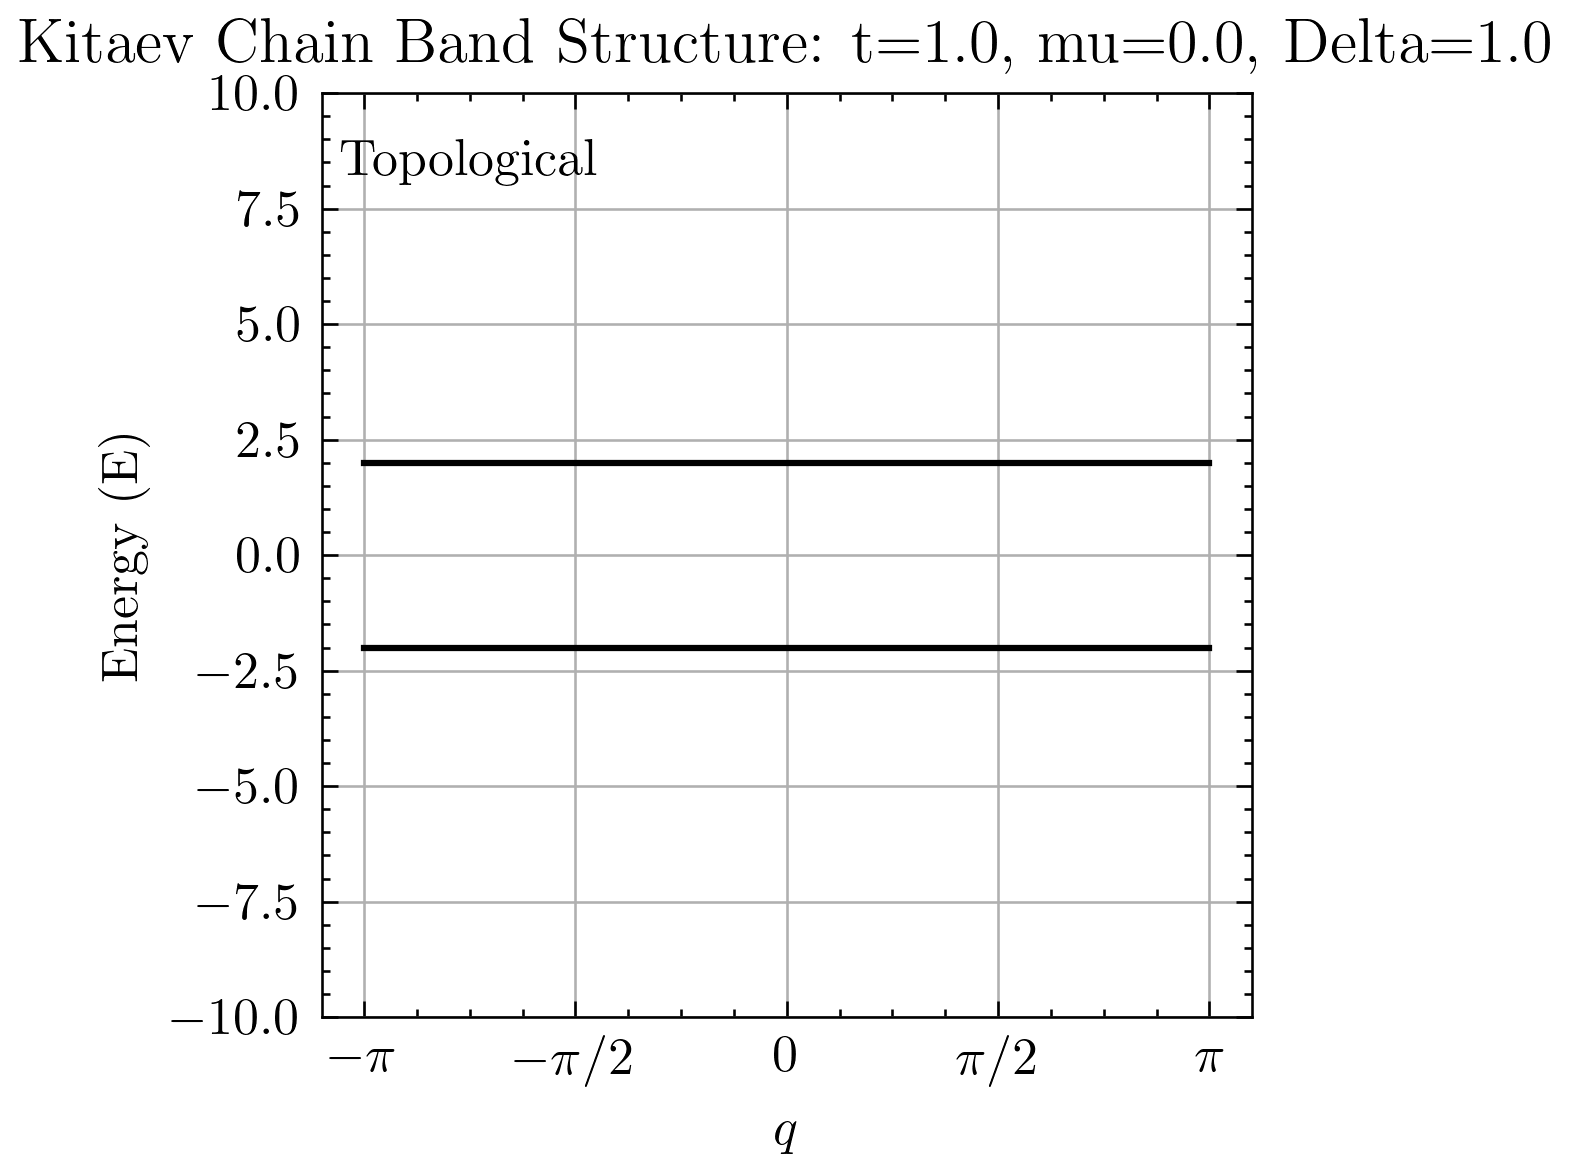

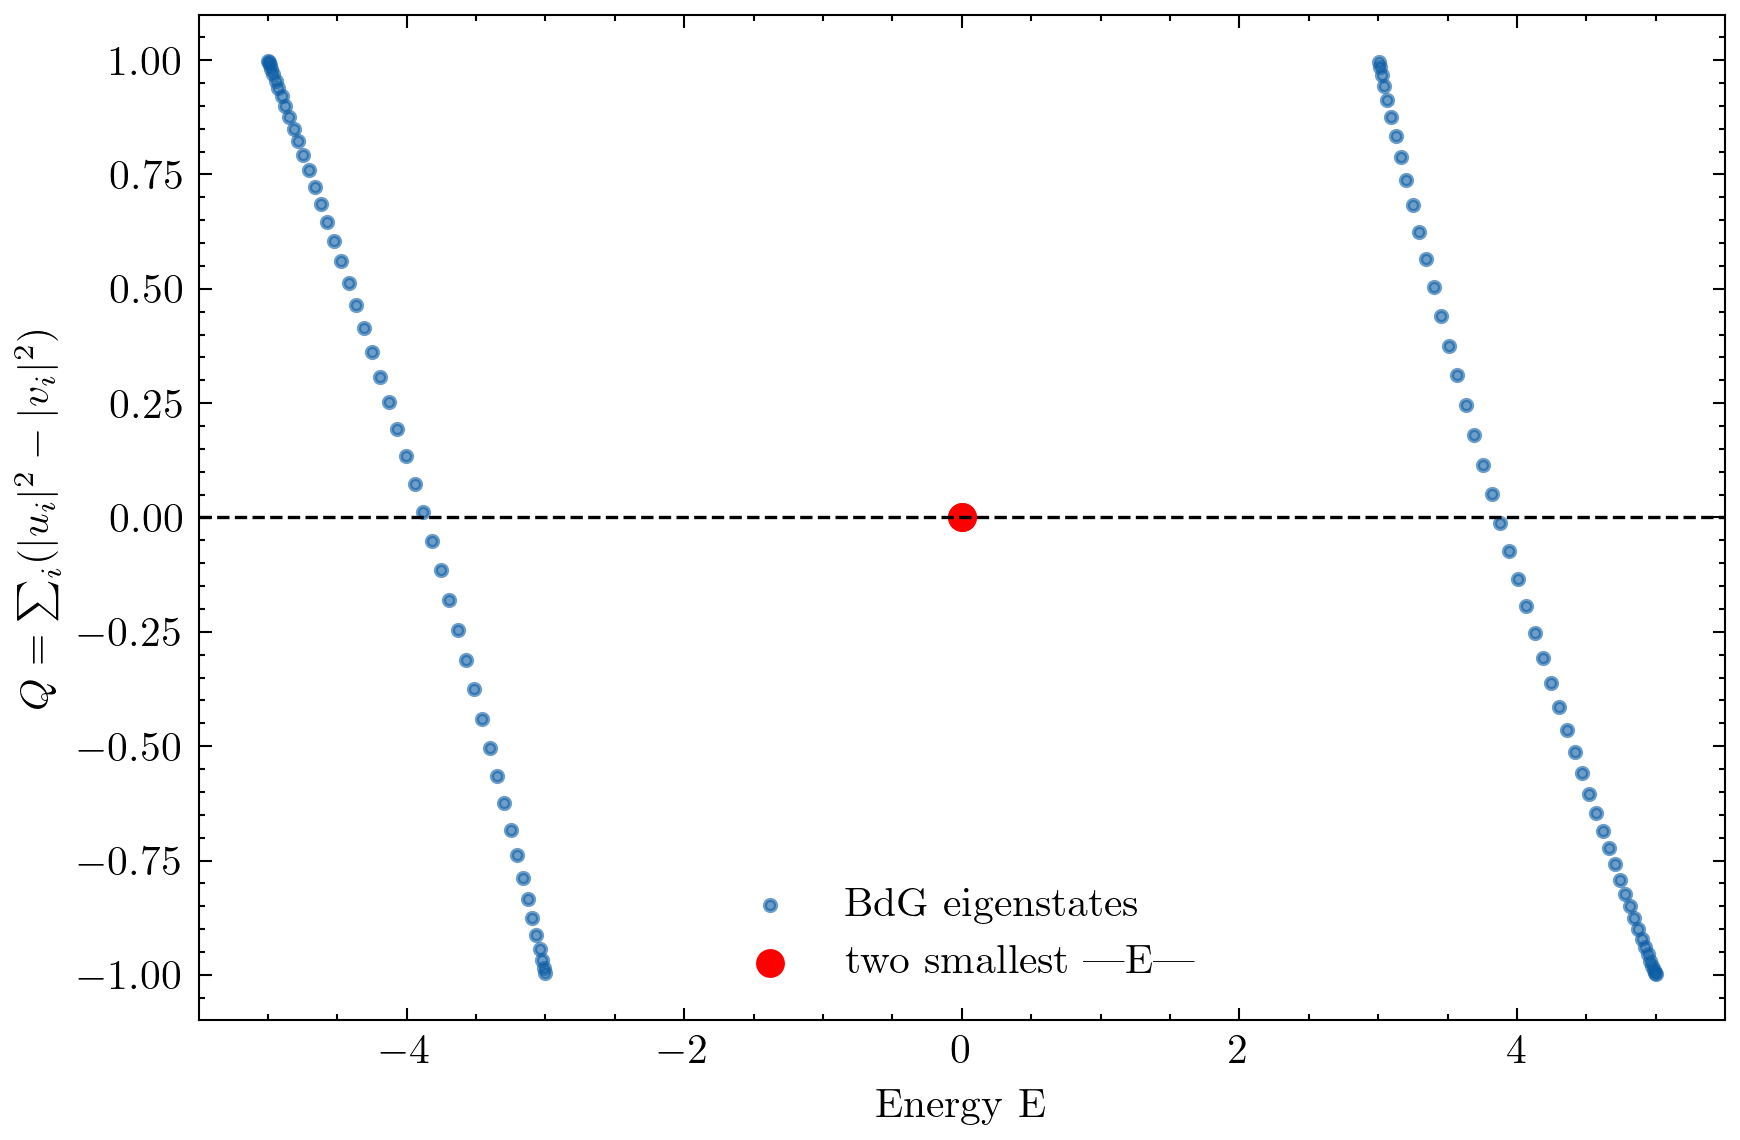

Edge weight (eta_L): 1.000
Edge weight (eta_R): 1.000


In [65]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# Use raw eigensystem from your current chain setup
# eigvals: (2N,), eigvecs: (2N, 2N) with eigenvectors in columns
# if 'chain' in globals() and getattr(chain, 'hamiltonian', None) is not None:
#     eigvals, eigvecs = chain.compute_eigensystem()
# else:
#     raise RuntimeError('Please build `chain` and Hamiltonian first.')
chain = KitaevChain(n_sites=N)
chain.build_hamiltonian(t, mu, d)
eigvals, eigvecs = chain.compute_eigensystem()

N = eigvecs.shape[0] // 2

def bdg_charge(vec):
    u = vec[:N]
    v = vec[N:]
    return np.sum(np.abs(u)**2 - np.abs(v)**2).real

def normalize(vec):
    nrm = np.sqrt(np.vdot(vec, vec).real)
    return vec / nrm

# 1) Charges of BdG eigenstates (usually nonzero individually)
charges = np.array([bdg_charge(eigvecs[:, i]) for i in range(eigvecs.shape[1])])

# 2) Pick the two lowest-|E| states (near-zero doublet)
idx2 = np.argsort(np.abs(eigvals))[:2]
i1, i2 = idx2[0], idx2[1]
psi1 = eigvecs[:, i1]
psi2 = eigvecs[:, i2]

# Fix relative phase so overlap is real before combining
phase = np.vdot(psi1, psi2)
psi2 = psi2 * np.exp(-1j * np.angle(phase))

# 3) Majorana-like combinations from near-zero pair
eta_L = normalize((psi1 + psi2) / np.sqrt(2.0))
eta_R = normalize(1j * (psi1 - psi2) / np.sqrt(2.0))

Q1 = bdg_charge(psi1)
Q2 = bdg_charge(psi2)
QL = bdg_charge(eta_L)
QR = bdg_charge(eta_R)

print('Near-zero energies:', eigvals[idx2])
print('BdG-pair charges:    Q1 = {:.3e}, Q2 = {:.3e}, Q1+Q2 = {:.3e}'.format(Q1, Q2, Q1 + Q2))
print('Majorana-combo charge: QL = {:.3e}, QR = {:.3e}'.format(QL, QR))

# Plot Q(E) from raw BdG eigenstates and highlight the near-zero pair
plt.figure(figsize=(6, 4))
plt.axhline(0.0, color='k', lw=0.8, ls='--')
plt.scatter(eigvals, charges, s=7, alpha=0.6, label='BdG eigenstates')
plt.scatter(eigvals[idx2], charges[idx2], s=35, color='red', label='two smallest |E|')
plt.xlabel('Energy E')
plt.ylabel(r'$Q = \sum_i (|u_i|^2 - |v_i|^2)$')
plt.legend()
plt.tight_layout()
plt.show()

# Optional sanity check: edge localization of Majorana-like combinations
def spatial_density(vec):
    u = vec[:N]
    v = vec[N:]
    return np.abs(u)**2 + np.abs(v)**2

rhoL = spatial_density(eta_L)
rhoR = spatial_density(eta_R)
edge_sites = min(10, N // 5)
print('Edge weight (eta_L): {:.3f}'.format(np.sum(rhoL[:edge_sites]) + np.sum(rhoL[-edge_sites:])))
print('Edge weight (eta_R): {:.3f}'.format(np.sum(rhoR[:edge_sites]) + np.sum(rhoR[-edge_sites:])))

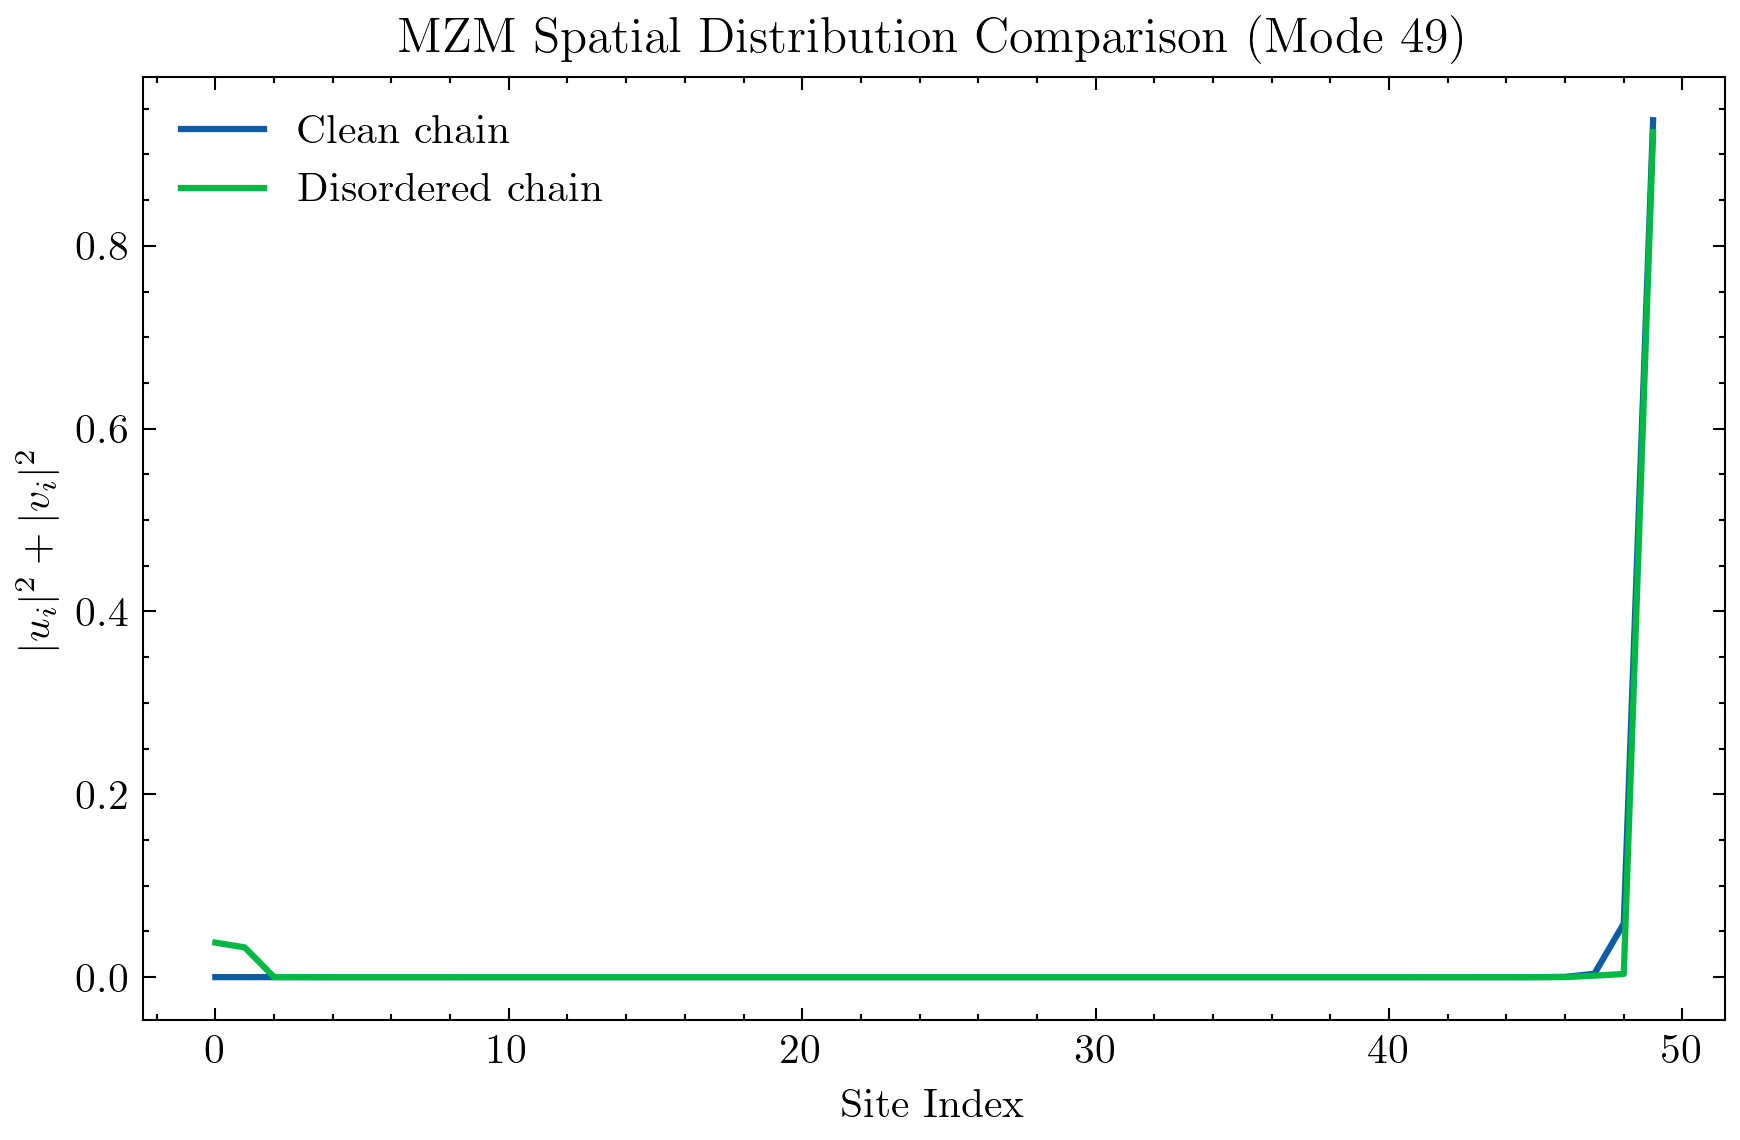

In [66]:
%matplotlib inline

# Compare MZM spatial profiles for clean vs disordered chains using existing function.
assert (eig_sys1.mzm_idx.size >= 2) and (eig_sys2.mzm_idx.size >= 2) and np.all(eig_sys1.mzm_idx == eig_sys2.mzm_idx)

mzm_idx = eig_sys1.mzm_idx
mode = mzm_idx[0]
clean_profile = eig_sys1.compute_spatial_distribution(eig_sys1.eigfunc[:, mode])
disordered_profile = eig_sys2.compute_spatial_distribution(eig_sys2.eigfunc[:, mode])

plt.figure(figsize=(6, 4))
plt.plot(clean_profile, label='Clean chain', linewidth=1.5)
plt.plot(disordered_profile, label='Disordered chain', linewidth=1.5)
plt.xlabel('Site Index')
plt.ylabel(r'$|u_i|^2 + |v_i|^2$')
plt.title(f'MZM Spatial Distribution Comparison (Mode {mode})')
plt.legend()
plt.tight_layout()
plt.show()